In [1]:
# Notebook for testing the whole flow; paraphrase MMLU Q, test on LLama 3/related models.

import argparse
import os, sys
import numpy as np
import pandas as pd
import time
import gc
import re
import random
import copy
import math
from matplotlib import pyplot as plt

import transformers
import torch

from transformers import LlamaForCausalLM, LlamaTokenizerFast

# Modified for testing the llama models
# using huggingface
# jlim@wpi.edu

KEYPATH = ""
with open(KEYPATH, 'r') as f:
    API_KEY = f.readline()
    API_KEY = API_KEY.rstrip('\n')

# LLaMA model links:
# https://huggingface.co/meta-llama/Llama-2-7b-chat/tree/main
# Nevermind, use this similar model instead:
# https://huggingface.co/meta-llama/Llama-2-7b-hf
# Example code for using transformers with the model. I used this as a starting point:
# https://medium.com/@lucnguyen_61589/llama-2-using-huggingface-part-1-3a29fdbaa9ed

# Try a bigger model...
# TEST_MODEL = "Llama-3.1-8B-Instruct"
# MODEL_REPO = "meta-llama/Llama-3.1-8B-Instruct"  # Other model does not have a chat template; no chat support?

TEST_MODEL = "Llama-3.2-3B-Instruct"
MODEL_REPO = "meta-llama/Llama-3.2-3B-Instruct"  # Other model does not have a chat template; no chat support?

GEN_TEMP = 1.0

EOT_STR = "<|eot_id|>"

DEVICE_STR = 'cuda'


# Training sets
PAWS_WIKI_PATH = '/home/jlim/MS_Project/validator_validation/paws_wiki_labeled_final/final/train.tsv'
PAWS_QQP_PATH = '/home/jlim/MS_Project/validator_validation/paws_qqp/output/train.tsv'

# PAWS_WIKI_PATH = '/home/jeremy/Documents/WPI_MS/Q_Inoculate/Q_Inoculate/validator_validation/paws_wiki_labeled_final/final/train.tsv'
# PAWS_QQP_PATH = '/home/jeremy/Documents/WPI_MS/Q_Inoculate/Q_Inoculate/validator_validation/paws_qqp/output/train.tsv'


# For short answers
MAX_NEW_TOKENS = 10

# For paraphrasing.
MAX_PARAPHRASE_TOKENS = 1000  # Roughly 2x the number of tokens for the longest question.

CHOICES = ["A", "B", "C", "D"]

BATCH_SIZE = 1  # one at a time for now. Avoids padding issues.


DATA_DIR = "/home/jlim/MS_Project/MMLU_Baseline/data"

ANSWER_STRING_MAP = {'0': "A", '1': "B", '2': "C", '3': "D"}

print("Data directory: " + str(DATA_DIR))


2025-03-26 18:02:04.722367: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-26 18:02:04.734507: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-26 18:02:04.754649: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-26 18:02:04.754674: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-26 18:02:04.767086: I tensorflow/core/platform/cpu_feature_gua

Data directory: /home/jlim/MS_Project/MMLU_Baseline/data


In [2]:
MAX_NEW_TOKENS = 10  # This is for very short responses


PARSE_RETRIES = 1 # 5 usually. 1 for no sampling.
# MAX_NEW_TOKENS = 1000 # Longer, to allow COT reasoning

# Function Defs
def eval_q(pipeline, q1, q2):
    # return the label that the model answers for a given prompt.
    # True means paraphrase, False means no paraphrase.

    # More testing - best so far
    verify_prompt = ("Do sentence 1 and sentence 2 have extremely different meanings? "
        "Remember that some sentences that are phrased differently have the same meaning. "
        "The sentences may appear different, but the wording may actually imply a very similar meaning. "
        "For your answer, please state either \"yes.\" or \"no.\" at the start of your answer."
        "\nSentence 1: '{q1}'"
        "\nSentence 2: '{q2}'\n")
    

    verify_msgs = [{"role": "user", "content": verify_prompt.format(q1=q1, q2=q2)}]

    successful_parse = False
    fail_count = 0
    while not successful_parse:

        prompt = pipeline.tokenizer.apply_chat_template(verify_msgs, tokenize=False, add_generation_prompt=True)

        # print("Model Prompt~~~~~~~~~~~~~~")
        # print(prompt)

        encoded_verify_request = pipeline.tokenizer(prompt, return_tensors="pt",
                                                    padding=False)  # Keeping padding off for now.

        # No gradients!
        with torch.no_grad():
            # Put on proper device?
            # Inspiration: https://discuss.huggingface.co/t/device-map-auto-with-error-expected-all-tensors-to-be-on-the-same-device/31938/6
            encoded_verify_request.to(DEVICE_STR)

            generated_output = pipeline.model.generate(**encoded_verify_request, do_sample=False, temperature=GEN_TEMP,
                                                    max_new_tokens=MAX_NEW_TOKENS,
                                                    return_dict_in_generate=True, output_scores=True, output_logits=True,
                                                    pad_token_id=pipeline.tokenizer.eos_token_id)

            # generated_output = generated_output.sequences[0][-MAX_NEW_TOKENS:]
            generated_output = generated_output.sequences[0][encoded_verify_request['input_ids'].shape[1]:]

            

            # Detokenize, convert to lowercase.
            generated_output = pipeline.tokenizer.decode(generated_output).lower()

            # Keep tensor memory clear!
            del encoded_verify_request

        # print("Model Response~~~~~~~~~~~~~~")
        # print(generated_output)

        if re.search("^yes", generated_output):  # Begin is "^yes"
            # yes
            # print("Parsed yes")
            # return True
            return False
        elif re.search("^no", generated_output):  # Begin is "^no"
            # no
            # print("Parsed no")
            # return False
            return True

        # if re.search(re.escape("yes.<|eot_id|>") + "$", generated_output):  # Begin is "^yes"
        #     # yes
        #     # print("Parsed yes")
        #     return True
        # elif re.search(re.escape("no.<|eot_id|>") + "$", generated_output):  # Begin is "^no"
        #     # no
        #     # print("Parsed no")
        #     return False

        else:
            fail_count += 1
            print("Response validation failure. Fail count: " + str(fail_count))
            # print("Failing Validation response:")
            # print(generated_output)
            if fail_count > PARSE_RETRIES:
                print("Could not generate a valid response!")
                return None

# Dummy function for local testing.
def eval_q_debug(pipeline, q1, q2):
    return random.choice([True, False])


In [3]:
# Set up data structures, model data.
# Load wiki paraphrase data.
print("Loading paraphrase data")
trainwiki_df = pd.read_csv(PAWS_WIKI_PATH, sep='\t')
trainqqp_df = pd.read_csv(PAWS_QQP_PATH, sep='\t')

# Load MMLU dev set
# read all questions
mmlu_subjects = sorted(
    [f.split("_test.csv")[0] for f in os.listdir(os.path.join(DATA_DIR, "test")) if "_test.csv" in f])

dev_df = None
for subject in mmlu_subjects:
    # TODO: Separate by subject?
    if dev_df is None:
        dev_df = pd.read_csv(os.path.join(DATA_DIR, "dev", subject + "_dev.csv"), header=None)
    else:
        dev_df = pd.concat([dev_df, pd.read_csv(os.path.join(DATA_DIR, "dev", subject + "_dev.csv"), header=None)])
        
num_qs = dev_df.shape[0]
print("Dev dataset size: " + str(num_qs))

pipeline = None
print("Initializing model & pipeline...")
# Model, tokenizer, pipeline init
device_map_setting = DEVICE_STR  # 'auto'  # 'cuda'

model = transformers.AutoModelForCausalLM.from_pretrained(
    MODEL_REPO,
    token=API_KEY,
    device_map=device_map_setting
)

# Set to eval mode!
# https://discuss.huggingface.co/t/inference-without-gradient-computation/14449
model.eval()

tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_REPO, token=API_KEY)

if torch.cuda.is_available():
    print("GPU available...")
else:
    print("No GPU available...")

pipeline = transformers.pipeline(
    "text-generation",
    model=model,
    torch_dtype=torch.float16,  # Probably won't work on cpu...
    tokenizer=tokenizer,
    device_map=device_map_setting,
)

Loading paraphrase data
Dev dataset size: 285
Initializing model & pipeline...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda


GPU available...


In [10]:
# Supporting functions

# Define support functions.
def ask_q(pipeline, question_list):
    # Ask the Q, get the response.
    # Use llama prompt format, though with no examples.
    prompt_turn_string = ("Given the following question and four candidate answers (A, B, C and D), choose the best answer.\nQuestion: {}\n"
                          "Your response should end with \"The best answer is [the_answer_letter]\" where the [the_answer_letter] is one of A, B, C or D.")

    # Only used for prompting with examples.
    # response_template = "\n\nThe best answer is {}."

    promptlist = []
    for q in question_list:

        # return the choice string.
        msgs = [{"role": "user", "content": prompt_turn_string.format(q)}]

        # Return the completed template.
        prompt = pipeline.tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        promptlist.append(prompt)
    # print("Prompt:")
    # print(prompt)

    # Encode a batch to be processed at once.
    # Dealing with padding: https://huggingface.co/docs/transformers/en/pad_truncation
    encoded = pipeline.tokenizer(promptlist, return_tensors="pt", padding=False)  # padding=True

    # TEST: can you batch?
    # encoded = pipeline.tokenizer([prompt, prompt], return_tensors="pt")

    # Put on proper device?
    # Inspiration: https://discuss.huggingface.co/t/device-map-auto-with-error-expected-all-tensors-to-be-on-the-same-device/31938/6
    encoded.to(DEVICE_STR)


    generated_output = pipeline.model.generate(**encoded, do_sample=True, temperature=GEN_TEMP, max_new_tokens=MAX_NEW_TOKENS,
                                      return_dict_in_generate=True, output_scores=True, output_logits=True)

    # Free memory
    del encoded

    respset = []
    for i in range(len(question_list)):
        # Subject to MAX_NEW_TOKENS limit
        
        respset.append(pipeline.tokenizer.decode(generated_output.sequences[i][-MAX_NEW_TOKENS:]))

    return respset


COMPLIANCE_RETRIES = 5  # Sometimes the LLM doesn't even follow our format. Retry until it does...

# Non batched question ask
# Define support functions.
def ask_q_single(pipeline, question):
    # Ask the Q, get the response.
    # Use llama prompt format, though with no examples.
    prompt_turn_string = ("Given the following question and four candidate answers (A, B, C and D), choose the best answer.\nQuestion: {}\n"
                          "Your response should end with \"The best answer is [the_answer_letter]\" where the [the_answer_letter] is one of A, B, C or D.")

    # Only used for prompting with examples.
    # response_template = "\n\nThe best answer is {}."

    answer_match_regex = "The best answer is [ABCD]"

    # return the choice string.
    msgs = [{"role": "user", "content": prompt_turn_string.format(question)}]

    # Return the completed template.
    prompt = pipeline.tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)

    # Encode a batch to be processed at once.
    # Dealing with padding: https://huggingface.co/docs/transformers/en/pad_truncation
    encoded = pipeline.tokenizer([prompt], return_tensors="pt", padding=False)  # padding=True

    # TEST: can you batch?
    # encoded = pipeline.tokenizer([prompt, prompt], return_tensors="pt")

    # Put on proper device?
    # Inspiration: https://discuss.huggingface.co/t/device-map-auto-with-error-expected-all-tensors-to-be-on-the-same-device/31938/6
    encoded.to(DEVICE_STR)

    strmatches = []
    trials = -1

    while len(strmatches) == 0:
        trials += 1
        if(trials > COMPLIANCE_RETRIES):
            print("Could not generate compliant response. Try #: " + str(trials))
            return None

        generated_output = pipeline.model.generate(**encoded, do_sample=True, temperature=GEN_TEMP, max_new_tokens=MAX_NEW_TOKENS,
                                        return_dict_in_generate=True, output_scores=True, output_logits=True, pad_token_id=pipeline.tokenizer.eos_token_id)

        retval = pipeline.tokenizer.decode(generated_output.sequences[0][encoded['input_ids'].shape[1]:])

        strmatches = re.findall(answer_match_regex, retval)


    # Free memory
    del encoded

    return strmatches[-1]

# Modified MMLU format function.
def format_question_single(df, idx, include_answer=True):
    prompt = df.iloc[idx, 0]
    k = df.shape[1] - 2  # answer index.
    for j in range(k):
        prompt += "\n{}. {}".format(CHOICES[j], df.iloc[idx, j+1])

    if include_answer:
        prompt += "\nAnswer:"
        prompt += " {}\n\n".format(df.iloc[idx, k + 1])
    return prompt

def format_para_question_single(base_q, df, idx, include_answer=True):
    prompt = base_q
    k = df.shape[1] - 2  # answer index.
    for j in range(k):
        prompt += "\n{}. {}".format(CHOICES[j], df.iloc[idx, j+1])

    if include_answer:
        prompt += "\nAnswer:"
        prompt += " {}\n\n".format(df.iloc[idx, k + 1])
    return prompt

In [5]:
# Will try using logprobs to calculate some threshold score
# Inspiration: https://discuss.huggingface.co/t/compute-log-probabilities-of-any-sequence-provided/11710/6

# Might let me detect paraphrases using a generation task - more options to try to improve performance.

def get_prompt_gen_logprob(pipeline, prompt, q1, q2):
    # q1 is substituted into the prompt.
    model_query = [{"role": "user", "content": prompt.format(q1=q1)}]

    # Get the tokens for our desired response.
    test_response = pipeline.tokenizer(q2, padding=False, return_tensors="pt")  # Keeping padding off for now.

    test_response.to(DEVICE_STR)

    # other_response = pipeline.tokenizer("." + q2 +".", padding=False)

    # print(pipeline.tokenizer.decode(test_response['input_ids']))
    # print(pipeline.tokenizer.decode(other_response['input_ids']))

    test_ids = test_response['input_ids'][0][1:] # Skip the first token; usually adds begin-of-text token.

    test_num_tokens = test_ids.shape[0]

    # one-time query
    prompt = pipeline.tokenizer.apply_chat_template(model_query, tokenize=False, add_generation_prompt=True)


    encoded_request = pipeline.tokenizer(prompt, return_tensors="pt",
                                                padding=False)  # Keeping padding off for now.

    # print("Model Prompt~~~~~~~~~~~~~~")
    # print(prompt)

    logits_sequence = []

    # No gradients!
    with torch.no_grad():

        in_ids = copy.deepcopy(encoded_request)

        in_ids.to(DEVICE_STR)

        in_ids = in_ids['input_ids']

        # print("Device id: " + str(in_ids.get_device()))

        # Code adapted from here: https://discuss.huggingface.co/t/generate-without-using-the-generate-method/11379
        # TODO: Can transform into batched form? We know all of the needed variations ahead of time...
        # NOTE: I think the model response isn't some starting character, but it could affect the logic here...
        for a in range(test_num_tokens):
            outputs = pipeline.model(input_ids=in_ids)
            logits = outputs.logits[:, -1, :]
            logits_sequence.append(logits)

            # Force the next token to be what I want.
            # Put this on the GPU - TODO: Make more efficient.
            # add_tensor = torch.tensor([[test_ids[a]]])
            # add_tensor.to(DEVICE_STR)

            # print("Device id: " + str(in_ids.get_device()))
            # print("Device id: " + str(add_tensor.get_device()))

            in_ids = torch.concat([in_ids, torch.unsqueeze(torch.unsqueeze(test_ids[a], dim=0), dim=0)], dim=1)
            # in_ids = torch.concat([in_ids, predicted_id])

        del in_ids
        del test_response

        # Compute logsumexp.
        logits_sequence = torch.concat(logits_sequence, dim=0)

        # Re-index by our given sequence.

        # Remembering how to use logsumexp:
        # https://gregorygundersen.com/blog/2020/02/09/log-sum-exp/

        return get_sequence_odds_log(logits_sequence, test_ids) # , alpha=0.8


def get_sequence_odds(logits_tensor, selected_tokens_list, alpha=0.8):
    # Compare to softmaxing & mult.

    forced_logits = logits_tensor[list(range(len(selected_tokens_list))), selected_tokens_list]

    # Softmax, but in logits world.
    forced_token_logits = forced_logits - torch.logsumexp(logits_tensor, dim=1)

    sequence_prob = torch.exp(torch.sum(forced_token_logits)) / math.pow(float(len(selected_tokens_list)), alpha)

    return sequence_prob.item()

# Don't adjust for sequence length in this version.
def get_sequence_odds_simple(logits_tensor, selected_tokens_list):
    # Compare to softmaxing & mult.

    forced_logits = logits_tensor[list(range(len(selected_tokens_list))), selected_tokens_list]

    # Softmax, but in logits world.
    forced_token_logits = forced_logits - torch.logsumexp(logits_tensor, dim=1)

    sequence_prob = torch.exp(torch.sum(forced_token_logits))

    return sequence_prob.item()

# Live in Log world.
def get_sequence_odds_log(logits_tensor, selected_tokens_list):
    # Compare to softmaxing & mult.

    forced_logits = logits_tensor[list(range(len(selected_tokens_list))), selected_tokens_list]

    # Softmax, but in logits world.
    forced_token_logits = forced_logits - torch.logsumexp(logits_tensor, dim=1)

    sequence_prob = torch.sum(forced_token_logits)

    # In log world, higher value means higher likelyhood still.
    return sequence_prob.item()


def relative_score(pipeline, prompt, q1, q2):
    # Given the prompt, get q2's perplexity offset from q1.
    return get_prompt_gen_logprob(pipeline, prompt, q1, q2) - get_prompt_gen_logprob(pipeline, prompt, q1, q1)

def pair_scores(pipeline, prompt, q1, q2):
    return (get_prompt_gen_logprob(pipeline, prompt, q1, q2), get_prompt_gen_logprob(pipeline, prompt, q1, q1))

# For testing above function, set to true.
if False:
    test_prompt_str = ("Repeat the provided sentence exactly, word for word."
                    "\nSentence: '{q1}'\n")
    q1 = "Hello world!"
    q2 = "Greetings Earth!"
    q3 = "Goodbye world!"
    q4 = "asdfasl;hirukyau"

    odds1 = get_prompt_gen_logprob(pipeline, test_prompt_str, q1, q1)
    odds2 = get_prompt_gen_logprob(pipeline, test_prompt_str, q1, q2)
    odds3 = get_prompt_gen_logprob(pipeline, test_prompt_str, q1, q3)
    odds4 = get_prompt_gen_logprob(pipeline, test_prompt_str, q1, q4)

    print("For Prompt 1: " + test_prompt_str)

    print(q1 + ": " + str(odds1))
    print(q2 + ": " + str(odds2))
    print(q3 + ": " + str(odds3))
    print(q4 + ": " + str(odds4))

    # Try the inverted
    test_prompt_str = ("Say a sentence that means the opposite of the provided sentence."
                       "\nSentence: '{q1}'\n")
    q1 = "Hello world!"
    q2 = "Greetings Earth!"
    q3 = "Goodbye world!"
    q4 = "asdfasl;hirukyau"

    invert_odds1 = get_prompt_gen_logprob(pipeline, test_prompt_str, q1, q1)
    invert_odds2 = get_prompt_gen_logprob(pipeline, test_prompt_str, q1, q2)
    invert_odds3 = get_prompt_gen_logprob(pipeline, test_prompt_str, q1, q3)
    invert_odds4 = get_prompt_gen_logprob(pipeline, test_prompt_str, q1, q4)

    print()
    print("For Prompt 2: " + test_prompt_str)

    print(q1 + ": " + str(invert_odds1))
    print(q2 + ": " + str(invert_odds2))
    print(q3 + ": " + str(invert_odds3))
    print(q4 + ": " + str(invert_odds4))

    

In [6]:
# Sometimes the model doesn't listen, and outputs stuff that doesn't follow the specified format
# This dictates how patient we'll be!
PARSE_RETRIES = 5

MAX_PARA_RETRIES = 20

test_q_num = 100

char_len_proportion = 0.5  # Paraphrase must be within +/- this proportion of the length of the original. Rough metric to remove incorrect answers.

# Rough test of full flow
# New prompt, related to prompt 1 but improving formatting because the double double quoting seems unusual.
# paraphrase_prompt = ("Please rewrite the following question using different words. "
#                      "The rewritten question should have the same meaning as the original. "
#                      "Your response should be enclosed in double quotes like the following format: \"<new question>\".\nOriginal Question: \'{}\'\n")


# paraphrase_prompt = ("Please rewrite the following question using different words. "
#                      "The rewritten question should have the same meaning as the original. "
#                      "Your response should be surrounded in quotes like the following format: \'<new question>\'.\nOriginal Question: \'{}\'\n")

# Limited paraphrasing... Not the most general
paraphrase_prompt = ("Please paraphrase the following question by substituting words or phrases. "
                     "The paraphrased question should have the same meaning as the original. "
                     "Your response should be surrounded in quotes like the following format: \'<new question>\'.\nOriginal Question: \'{}\'\n")

# New prompt; fix parse failures?

# eval_task_prompt = ("Please write a single paraphrase of the provided question. Provide only the paraphrased question as the response. Provide no other commentary."
#                        "\nQuestion: '{q1}'\n")



para_fails_set = []

for a in range(test_q_num):  # Outer loop under construction

    rand_idx = random.choice(range(dev_df.shape[0]))

    question_no_choices = dev_df.iloc[rand_idx, 0]

    question_str = format_question_single(dev_df, rand_idx, include_answer=False)

    # print("Question; no answers: " + str(question_no_choices))
    # print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # print("Test question: " + str(question_str))
    # print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

    # continue

    # Debugging, dummy prompt:
    # paraphrase_prompt = ("Please output the following string: \"\"hello world.\"\""

    # Sometimes, you cannot separate the question and the answers!
    # paraphrase_msgs = [{"role": "user", "content": paraphrase_prompt.format(question_str)}]  # question_no_choices

    # Paraphrase without responses
    paraphrase_msgs = [{"role": "user", "content": paraphrase_prompt.format(question_no_choices)}]  # question_no_choices

    successful = False
    parse_fail_count = 0
    para_q = None
    para_fail_count = 0

    prompt = pipeline.tokenizer.apply_chat_template(paraphrase_msgs, tokenize=False, add_generation_prompt=True)
    encoded_paraphrase_request = pipeline.tokenizer(prompt, return_tensors="pt", padding=False) # Turning padding off for now

    # Put on proper device?
    # Inspiration: https://discuss.huggingface.co/t/device-map-auto-with-error-expected-all-tensors-to-be-on-the-same-device/31938/6
    encoded_paraphrase_request.to(DEVICE_STR)

    while not successful:

        generated_output = pipeline.model.generate(**encoded_paraphrase_request, do_sample=True, temperature=GEN_TEMP, max_new_tokens=MAX_PARAPHRASE_TOKENS,
                                            return_dict_in_generate=True, output_scores=True, output_logits=True, pad_token_id=pipeline.tokenizer.eos_token_id)

        # generated_output = generated_output.sequences[0][-MAX_PARAPHRASE_TOKENS:]
        generated_output = generated_output.sequences[0][encoded_paraphrase_request['input_ids'].shape[1]:]

        # Detokenize
        generated_output = pipeline.tokenizer.decode(generated_output)

        # print("Model output ~~~~~~~~~~~~~~~~~~~")
        # print(generated_output)
        # continue

        # result = re.search("\"\".*\"\"", generated_output)

        # The prompt has a string that matches this. Ignore this by getting only the last match!
        # all_matches = re.findall("\"\".*\"\"", generated_output)
        all_matches = re.findall("[\"\'].*[\"\']", generated_output)  # Switching to single double quotes
        # all_matches = all_matches[1:]  # Exclude first match; that was the original question.

        # The llm tends to put many extra quotes around stuff, chaotically. We look for both quote cases.

        # Just look at the last match.
        if len(all_matches) == 0:
            result = None
        else:
            result = all_matches[-1]

        if result is not None:
            # para_q = generated_output[result.start():result.end()]
            para_q = result
            para_q = para_q.strip("\"\'")

            # print("Paraphrase response:")
            # print(generated_output)
            # print("~~~~~~~~~~~~~~~~~~~~~")

            # print("Number of parse retries: " + str(fail_count))
            # print("Paraphrased question; original:")
            # print(para_q)
            # print(question_no_choices)

            # print("Comparing to: " + str(question_no_choices))
            is_paraphrase = eval_q(pipeline, question_no_choices, para_q)
            is_identical = (question_no_choices == para_q)
            is_nonempty = len(para_q) > 0
            is_proportion = (len(para_q) > len(question_no_choices) - char_len_proportion*len(question_no_choices)) and (len(para_q) < len(question_no_choices) + char_len_proportion*len(question_no_choices))

            # print("Orig len: " + str(len(question_no_choices)))
            # print("Para len: " + str(len(para_q)))

            # print("Is paraphrase?: " + str(is_paraphrase))
            # print("Is identical?: " + str(is_identical))
            # print("Is nonempty?: " + str(is_nonempty))
            # print("Meets proportion requirements?: " + str(is_proportion))

            if is_paraphrase and (not is_identical) and is_nonempty and is_proportion:
                successful = True
                para_fails_set.append(para_fail_count)

                # Keep tensor memory clear!
                del encoded_paraphrase_request
            else:
                para_fail_count += 1
                # need to retry.

                if para_fail_count > MAX_PARA_RETRIES:
                    print("Could not validate paraphrase response!")
                    para_fails_set.append(para_fail_count)
                    break

        else:
            parse_fail_count += 1
            # print("Failing Paraphrase response:")
            # print(generated_output)
            if parse_fail_count > PARSE_RETRIES:
                # Fallback to not paraphrasing?
                print("Could not parse a valid paraphrase response!")
                break


# average_para_runs = np.mean(para_fails_set)
print("Min num of reruns before successful paraphrase eval: " + str(np.min(para_fails_set)))
print("Average num of reruns before successful paraphrase eval: " + str(np.mean(para_fails_set)))
print("Max num of reruns before successful paraphrase eval: " + str(np.max(para_fails_set)))

# Okay, remember this example. It's MC but it's a completion task!

# The pleura
# A. have no sensory innervation.
# B. are separated by a 2 mm space.
# C. extend into the neck.
# D. are composed of respiratory epithelium.

# Note 2: Sometimes it ignores the answers, sometimes it doesn't

From v4.47 onwards, when a model cache is to be returned, `generate` will return a `Cache` instance instead by default (as opposed to the legacy tuple of tuples format). If you want to keep returning the legacy format, please set `return_legacy_cache=True`.
/home/jlim/miniconda3/envs/q_inoculate/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


Could not validate paraphrase response!
Could not validate paraphrase response!
Could not validate paraphrase response!
Could not validate paraphrase response!
Could not validate paraphrase response!
Could not validate paraphrase response!
Could not validate paraphrase response!
Could not validate paraphrase response!
Could not validate paraphrase response!
Could not validate paraphrase response!
Could not validate paraphrase response!
Min num of reruns before successful paraphrase eval: 0
Average num of reruns before successful paraphrase eval: 3.04
Max num of reruns before successful paraphrase eval: 21


In [ ]:
# Collect data on questions that the model would answer incorrectly!
# Can performance be significantly degraded by brute force?
ANSWER_PREFIX = "The best answer is {}"

# Sometimes the model doesn't listen, and outputs stuff that doesn't follow the specified format
# This dictates how patient we'll be!
PARSE_RETRIES = 5

MAX_PARA_RETRIES = 20

MAX_ATTACKS = 20  # Try this many paraphrases before giving up.

PARA_TEMP = 1.2  # default: 1.0

test_q_num = 100

char_len_proportion = 0.5  # Paraphrase must be within +/- this proportion of the length of the original. Rough metric to exclude obviously wrong paraphrases.


paraphrase_prompt = ("Please paraphrase the following question by substituting words or phrases. "
                     "The paraphrased question should have the same meaning as the original. "
                     "Your response should be surrounded in quotes like the following format: \'<new question>\'.\nOriginal Question: \'{}\'\n")

# New prompt; fix parse failures?

# eval_task_prompt = ("Please write a single paraphrase of the provided question. Provide only the paraphrased question as the response. Provide no other commentary."
#                        "\nQuestion: '{q1}'\n")

num_rephrases = []  # Count how often we need to rephrase questions to get incorrect answers.

for q_idx in range(dev_df.shape[0]): 
    print("Question: " + str(q_idx+1) + "/" + str(dev_df.shape[0]))
    # Get MMLU dev question

    # Check; original formulation; did llama get it correct, or incorrect?
    orig_question_no_choices = dev_df.iloc[q_idx, 0]

    label = dev_df.iloc[q_idx, dev_df.shape[1]-1]  # Last column.

    orig_question_str = format_question_single(dev_df, q_idx, include_answer=False)
    question_str = orig_question_str
    # print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # print("Original question:\n" + question_str)
    # print("Correct answer: " + str(label))
    # print("")

    # format_para_question_single(base_q, df, idx, include_answer=False):

    attack_count = 0

    num_rephrases.append(0)

    answer = ask_q_single(pipeline, question_str)

    if(answer is None):
        print("Could not get LLM answer!")
        num_rephrases[-1] = -1
        continue

    # print("LLM answer: " + answer)
    # If we got it correct, try paraphrasing

    # Decision:
    # If answer is compliant, check if the output is correct
    # If answer is noncompliant, retry

    while ANSWER_PREFIX.format(label) in answer:  # TODO: Improve parsing here.
        attack_count += 1
        print("Attack attempt: " + str(attack_count))

        if attack_count > MAX_ATTACKS:
            print("Could not attack question; continuing to next question...")
            num_rephrases[-1] = -1
            break
        
        # print("Attack attempt: " + str(attack_count))

        # Paraphrase, try to get it incorrect.
        # Paraphrase without responses
        paraphrase_msgs = [{"role": "user", "content": paraphrase_prompt.format(orig_question_no_choices)}]  # question_no_choices

        successful = False
        parse_fail_count = 0
        para_q = None

        para_count = 0

        prompt = pipeline.tokenizer.apply_chat_template(paraphrase_msgs, tokenize=False, add_generation_prompt=True)
        encoded_paraphrase_request = pipeline.tokenizer(prompt, return_tensors="pt", padding=False) # Turning padding off for now

        # Put on proper device?
        # Inspiration: https://discuss.huggingface.co/t/device-map-auto-with-error-expected-all-tensors-to-be-on-the-same-device/31938/6
        encoded_paraphrase_request.to(DEVICE_STR)

        while not successful:
            para_count += 1
            # print("Paraphrase attempt: " + str(para_count))
            if para_count > MAX_PARA_RETRIES:
                break

            generated_output = pipeline.model.generate(**encoded_paraphrase_request, do_sample=True, temperature=PARA_TEMP, max_new_tokens=MAX_PARAPHRASE_TOKENS,
                                                return_dict_in_generate=True, output_scores=True, output_logits=True, pad_token_id=pipeline.tokenizer.eos_token_id)

            # generated_output = generated_output.sequences[0][-MAX_PARAPHRASE_TOKENS:]
            generated_output = generated_output.sequences[0][encoded_paraphrase_request['input_ids'].shape[1]:]

            # Detokenize
            generated_output = pipeline.tokenizer.decode(generated_output)

            # print("Model output ~~~~~~~~~~~~~~~~~~~")
            # print(generated_output)
            # continue

            # result = re.search("\"\".*\"\"", generated_output)

            # The prompt has a string that matches this. Ignore this by getting only the last match!
            # all_matches = re.findall("\"\".*\"\"", generated_output)
            all_matches = re.findall("[\"\'].*[\"\']", generated_output)  # Switching to single double quotes
            # all_matches = all_matches[1:]  # Exclude first match; that was the original question.

            # The llm tends to put many extra quotes around stuff, chaotically. We look for both quote cases.

            # Just look at the last match.
            if len(all_matches) == 0:
                result = None
            else:
                result = all_matches[-1]

            if result is not None:
                # para_q = generated_output[result.start():result.end()]
                para_q = result
                para_q = para_q.strip("\"\'")

                # print("Paraphrase response:")
                # print(generated_output)
                # print("~~~~~~~~~~~~~~~~~~~~~")

                # print("Number of parse retries: " + str(fail_count))
                # print("Paraphrased question; original:")
                # print(para_q)
                # print(question_no_choices)

                # print("Comparing to: " + str(question_no_choices))
                is_paraphrase = eval_q(pipeline, orig_question_no_choices, para_q)
                is_identical = (orig_question_no_choices == para_q)
                is_nonempty = len(para_q) > 0
                is_proportion = (len(para_q) > len(orig_question_no_choices) - char_len_proportion*len(orig_question_no_choices)) and (len(para_q) < len(orig_question_no_choices) + char_len_proportion*len(orig_question_no_choices))

                # print("Orig len: " + str(len(question_no_choices)))
                # print("Para len: " + str(len(para_q)))

                # print("Is paraphrase?: " + str(is_paraphrase))
                # print("Is identical?: " + str(is_identical))
                # print("Is nonempty?: " + str(is_nonempty))
                # print("Meets proportion requirements?: " + str(is_proportion))

                if is_paraphrase and (not is_identical) and is_nonempty and is_proportion:
                    # Keep tensor memory clear!
                    del encoded_paraphrase_request

                    
                    # para_fails_set.append(para_fail_count)

                    question_str = format_para_question_single(para_q, dev_df, q_idx, include_answer=False)
                    # Update question_str with paraphrase
                    # print("Paraphrased question:\n" + question_str)
                    # We needed another try.
                    num_rephrases[-1] = num_rephrases[-1] + 1

                    answer = ask_q_single(pipeline, question_str)
                    # print("LLM answer: " + answer)

                    if(answer is None):
                        print("Could not get LLM answer!")
                        num_rephrases[-1] = -1
                        break

                    successful = True

                # else:

                #     if para_fail_count > MAX_PARA_RETRIES:
                #         print("Could not validate paraphrase response!")
                #         # num_rephrases[-1] = -1
                #         break

            else:
                parse_fail_count += 1
                # print("Failing Paraphrase response:")
                # print(generated_output)
                if parse_fail_count > PARSE_RETRIES:
                    # Fallback to not paraphrasing?
                    print("Could not parse a valid paraphrase response!")
                    # num_rephrases[-1] = -1
                    break

        if not successful:  # Could not paraphrase!
            print("Could not paraphrase question; continuing to next question...")
            num_rephrases[-1] = -1
            break

# Noted issues, plus ideas for quick fixes
# -Incorrect paraphrases (No fixes known)

# Answer noncompliance!
# -Better parsing strategy: Detect whether an answer is compliant or not.

# -Some questions the evaluator does not accept a paraphrase, consistently!
# --Just try increasing temp!
# --Second+ order paraphrases? Paraphrase a paraphrase-> compare to original.

# -Some questions are very resistant to paraphrasing - even 20 attacks don't change the answer.
# --Scramble question/answer order, formatting.
# --paraphrase confounding answers.

# -Low efficiency: combo of many issues makes evaluation a crawl...
# --No ideas so far...
# Roughly 50-50 between paraphrase fails, and attack fails.

# Complicated fix:
# Decoding based on future objective? How to choose the best token to maximise the odds of a future string being generated?
# May or may not be the very next string...
# Dumb: Assume it's the next string!
# Basically: Multi-objective prompt generation (prompt superposition)
    

Question: 1/285
Question: 2/285
Question: 3/285
Attack attempt: 1
Question: 4/285
Question: 5/285
Question: 6/285
Attack attempt: 1
Question: 7/285
Question: 8/285
Attack attempt: 1
Could not paraphrase question; continuing to next question...
Question: 9/285
Attack attempt: 1
Attack attempt: 2
Attack attempt: 3
Attack attempt: 4
Question: 10/285
Attack attempt: 1
Attack attempt: 2
Attack attempt: 3
Attack attempt: 4
Attack attempt: 5
Attack attempt: 6
Attack attempt: 7
Attack attempt: 8
Attack attempt: 9
Attack attempt: 10
Attack attempt: 11
Attack attempt: 12
Question: 11/285
Attack attempt: 1
Question: 12/285
Attack attempt: 1
Attack attempt: 2
Question: 13/285
Could not generate compliant response. Try #: 6
Could not get LLM answer!
Question: 14/285
Attack attempt: 1
Question: 15/285
Attack attempt: 1
Could not paraphrase question; continuing to next question...
Question: 16/285
Attack attempt: 1
Question: 17/285
Attack attempt: 1
Attack attempt: 2
Attack attempt: 3
Attack attempt:

[0, 0, 1, 0, 0, 1, 0, -1, 4, 12, 1, 2, -1, 1, -1, 1, -1, 12, 0, 0, -1, 0, 0, 1, -1, 0, 1, 0, 0, -1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, -1, 0, 0, -1, -1, 0, 4, 4, -1, 0, 0, 2, 2, 8, -1, -1, -1, -1, 4, 1, 1, 1, 0, 0, 0, 0, 0, -1, 1, 0, 0, 1, 0, 0, 0, -1, 0, 0, 2, 0, -1, -1, 0, 0, 0, 0, 1, 0, -1, 11, 3, -1, 0, 0, 8, 0, -1, 1, -1, 2, -1, 0, 1, -1, -1, -1, 0, -1, 0, -1, -1, 0, 0, 15, 2, -1, 0, -1, 0, -1, -1, 2, -1, -1, -1, 0, 8, -1, 3, 0, 0, 0, -1, 1, 1, -1, 0, 0, -1, 3, 1, -1, 3, 0, 0, 0, -1, -1, -1, -1, 0, -1, -1, 3, -1, -1, 0, 4, 0, -1, 0, -1, 0, -1, -1, 5, 1, 0, 0, 3, -1, -1, -1, 0, 5, 0, 0, 0, -1, 0, 2, -1, -1, 0, 7, 0, 1, 0, 0, 0, 0, 5, -1, -1, -1, -1, 8, 0, 0, -1, 0, 0, -1, 0, -1, 1, 1, 2, 0, -1, -1, 4, 16, 0, -1, 0, -1, 0, 0, 0, 2, 0, -1, 4, 0, -1, -1, 8, -1, 0, -1, 1, 0, 0, -1, 1, 4, 7, 0, 0, 13, 0, 1, -1, 0, -1, 20, 0, -1, 1, 1, 0, 3, 0, 2, 2, 0, 0, 4, -1, 1, -1, 1, 0, 3, -1, -1, 0, -1, 1, -1, 0, -1, 0, 0, -1, 1, 0, 11, 0, -1, 1, -1]


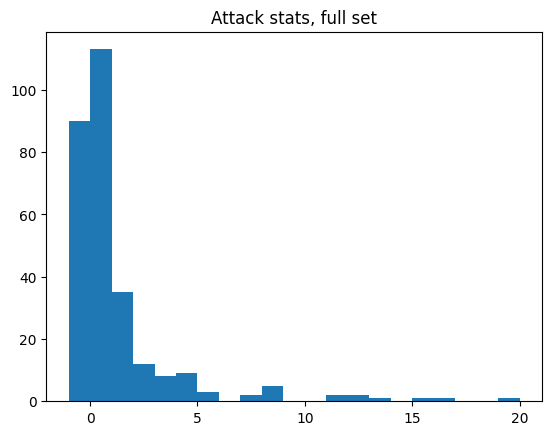

Number of question: 285
Number of questions incorrectly answered: 113
Number of attacked questions: 82
Proportion of successful attacks: 0.47674418604651164


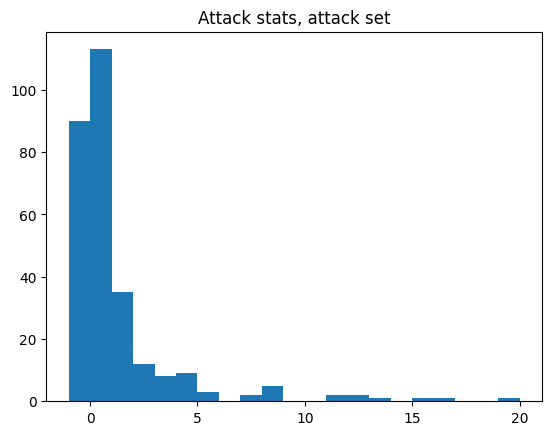

In [26]:
# Above cell: takes 63 minutes in current formulation!

import pickle

# with open('/home/jlim/MS_Project/Paraphrase_Attack/num_rephrases.pickle', 'wb') as f:
#     pickle.dump(num_rephrases, f)

# plot num_rephrases
print(num_rephrases)

plt.hist(num_rephrases, bins=list(range(-1,21)))
plt.title("Attack stats, full set", )

plt.show()

# filter list
# Includes questions the LLM got right, and we were able to attack to make it incorrect.
attacked_set = [x for x in num_rephrases if x > 0]

num_wrong_anyway = 0
for attacks in num_rephrases:
    if attacks == 0:
        num_wrong_anyway += 1

print("Number of question: " + str(len(num_rephrases)))
print("Number of questions incorrectly answered: " + str(num_wrong_anyway))
print("Number of attacked questions: " + str(len(attacked_set)))

print("Proportion of successful attacks: " + str(len(attacked_set) / (len(num_rephrases) - num_wrong_anyway)))

plt.hist(num_rephrases, bins=list(range(-1,21)))
plt.title("Attack stats, attack set", )

plt.show()

Run info

For 100 qs; at 11 minutes:

Min num of reruns before successful paraphrase eval: 0
Average num of reruns before successful paraphrase eval: 3.04
Max num of reruns before successful paraphrase eval: 21



Huge variety of questions on MMLU! May need to select a subset!!!

Question examples (written here)

Question; no answers: Which of the following sets has the smallest standard deviation? Which has the largest?
I: {1,2,3}
II: {-10,10}
III: {100}

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: Which of the following sets has the smallest standard deviation? Which has the largest?
I: {1,2,3}
II: {-10,10}
III: {100}

A. I, II
B. II, III
C. III, I
D. III, II
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: Suppose that f(1 + x) = f(x) for all real x. If f is a polynomial and f(5) = 11, then f(15/2)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: Suppose that f(1 + x) = f(x) for all real x. If f is a polynomial and f(5) = 11, then f(15/2)
A. -11
B. 0
C. 11
D. 33/2
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: As of 2019, about what percentage of Russians say it is very important to have free media in our country without government/state censorship?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: As of 2019, about what percentage of Russians say it is very important to have free media in our country without government/state censorship?
A. 38%
B. 53%
C. 68%
D. 83%
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: Which of these branches of the trigeminal nerve contain somatic motor processes?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: Which of these branches of the trigeminal nerve contain somatic motor processes?
A. The supraorbital nerve
B. The infraorbital nerve
C. The mental nerve
D. None of the above
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: A model airplane flies slower when flying into the wind and faster with wind at its back. When launched at right angles to the wind a cross wind its groundspeed compared with flying in still air is
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: A model airplane flies slower when flying into the wind and faster with wind at its back. When launched at right angles to the wind a cross wind its groundspeed compared with flying in still air is
A. the same
B. greater
C. less
D. either greater or less depending on wind speed
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: Glycolysis is the name given to the pathway involving the conversion of:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: Glycolysis is the name given to the pathway involving the conversion of:
A. glycogen to glucose-1-phosphate.
B. glycogen or glucose to fructose.
C. glycogen or glucose to pyruvate or lactate.
D. glycogen or glucose to pyruvate or acetyl CoA.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: A list of numbers has n elements, indexed from 1 to n. The following algorithm is intended to display the number of elements in the list that have a value greater than 100. The algorithm uses the variables count and position. Steps 3 and 4 are missing.
 Step 1: Set count to 0 and position to 1.
 Step 2: If the value of the element at index position is greater
 than 100, increase the value of count by 1.
 Step 3: (missing step)
 Step 4: (missing step)
 Step 5: Display the value of count.
 Which of the following could be used to replace steps 3 and 4 so that the algorithm works as intended?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: A list of numbers has n elements, indexed from 1 to n. The following algorithm is intended to display the number of elements in the list that have a value greater than 100. The algorithm uses the variables count and position. Steps 3 and 4 are missing.
 Step 1: Set count to 0 and position to 1.
 Step 2: If the value of the element at index position is greater
 than 100, increase the value of count by 1.
 Step 3: (missing step)
 Step 4: (missing step)
 Step 5: Display the value of count.
 Which of the following could be used to replace steps 3 and 4 so that the algorithm works as intended?
A. Step 3: Increase the value of position by 1.
 Step 4: Repeat steps 2 and 3 until the value of count is greater than 100.
B. Step 3: Increase the value of position by 1.
 Step 4: Repeat steps 2 and 3 until t he value of position is greater than n.
C. Step 3: Repeat step 2 until the value of count is greater than 100.
 Step 4: Increase the value of position by 1.
D. Step 3: Repeat step 2 until the value of position is greater than n.
 Step 4: Increase the value of count by 1.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: Ani believes that her attitudes and behavior play a central role in what happens to her. Such a belief is likely to be associated with
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: Ani believes that her attitudes and behavior play a central role in what happens to her. Such a belief is likely to be associated with
A. a strong superego.
B. low self-esteem.
C. low self-efficacy.
D. an internal locus of control.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: The energy for all forms of muscle contraction is provided by:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: The energy for all forms of muscle contraction is provided by:
A. ATP.
B. ADP.
C. phosphocreatine.
D. oxidative phosphorylation.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: Simplify and write the result with a rational denominator: $$\sqrt{\sqrt[3]{\sqrt{\frac{1}{729}}}}$$
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: Simplify and write the result with a rational denominator: $$\sqrt{\sqrt[3]{\sqrt{\frac{1}{729}}}}$$
A. \frac{3\sqrt{3}}{3}
B. \frac{1}{3}
C. \sqrt{3}
D. \frac{\sqrt{3}}{3}
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: On January 1, year 1, Alpha Co. signed an annual maintenance agreement with a software provider for $15,000 and the maintenance period begins on March 1, year 2. Alpha also incurred $5,000 of costs on January 1, year 1, related to software modification requests that will increase the functionality of the software. Alpha depreciates and amortizes its computer and software assets over five years using the straight-line method. What amount is the total expense that Alpha should recognize related to the maintenance agreement and the software modifications for the year ended December 31, year 1?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: On January 1, year 1, Alpha Co. signed an annual maintenance agreement with a software provider for $15,000 and the maintenance period begins on March 1, year 2. Alpha also incurred $5,000 of costs on January 1, year 1, related to software modification requests that will increase the functionality of the software. Alpha depreciates and amortizes its computer and software assets over five years using the straight-line method. What amount is the total expense that Alpha should recognize related to the maintenance agreement and the software modifications for the year ended December 31, year 1?
A. $5,000
B. $13,500
C. $16,000
D. $20,000
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: Which of the following persons is more likely to remain at home alone, as of 2019?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: Which of the following persons is more likely to remain at home alone, as of 2019?
A. An Asian man or woman
B. A Hispanic man
C. An African American woman
D. A white man or woman
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: A mutation in a bacterial enzyme changed a previously polar amino acid into a nonpolar amino acid. This amino acid was located at a site distant from the enzyme’s active site. How might this mutation alter the enzyme’s substrate specificity?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: A mutation in a bacterial enzyme changed a previously polar amino acid into a nonpolar amino acid. This amino acid was located at a site distant from the enzyme’s active site. How might this mutation alter the enzyme’s substrate specificity?
A. By changing the enzyme’s pH optimum
B. By changing the enzyme’s location in the cell
C. By changing the shape of the protein
D. An amino acid change away from the active site cannot alter the enzyme’s substrate specificity.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers:  In which dynasty was the "Mandate of Heaven" developed to legitimatize the new rulers?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question:  In which dynasty was the "Mandate of Heaven" developed to legitimatize the new rulers?
A. Shang
B. Zhou
C. Han
D. Xia
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: Which of the following is a correct statement about correlation?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: Which of the following is a correct statement about correlation?
A. If the slope of the regression line is exactly 1, then the correlation is exactly 1.
B. If the correlation is 0, then the slope of the regression line is undefined.
C. Switching which variable is called x and which is called y changes the sign of the correlation.
D. The correlation r is equal to the slope of the regression line when z-scores for the y-variable are plotted against z-scores for the x-variable.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: The rate of natural increase of a population is found by subtracting the
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: The rate of natural increase of a population is found by subtracting the
A. crude death rate from the crude birth date.
B. crude birth rate from the crude death rate.
C. doubling time from the crude birth rate.
D. fertility rate from the crude death rate.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: What place is named in the title of the 1979 live album by rock legends Cheap Trick?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: What place is named in the title of the 1979 live album by rock legends Cheap Trick?
A. Budapest
B. Budokan
C. Bhutan
D. Britain
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: What should a public relations media practitioner do if she does not know the answer to a reporter's question?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: What should a public relations media practitioner do if she does not know the answer to a reporter's question?
A. Give the reporter other information she is certain is correct.
B. Say that the information is 'off the record' and will be disseminated later.
C. Say 'I don't know' and promise to provide the information later.
D. Say 'no comment,' rather than appear uninformed.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: What is the first-line drug for patients with type 2 diabetes and obesity, as of 2020?

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: What is the first-line drug for patients with type 2 diabetes and obesity, as of 2020?

A. Acarbose
B. Metformin
C. Sulphonylureas
D. Insulin
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: How many attempts should you make to cannulate a patient before passing the job on to a senior colleague, according to the medical knowledge of 2020?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: How many attempts should you make to cannulate a patient before passing the job on to a senior colleague, according to the medical knowledge of 2020?
A. 4
B. 3
C. 2
D. 1
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: Let A be a real 2x2 matrix. Which of the following statements must be true?
I. All of the entries of A^2 are nonnegative.
II. The determinant of A^2 is nonnegative.
III. If A has two distinct eigenvalues, then A^2 has two distinct eigenvalues.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: Let A be a real 2x2 matrix. Which of the following statements must be true?
I. All of the entries of A^2 are nonnegative.
II. The determinant of A^2 is nonnegative.
III. If A has two distinct eigenvalues, then A^2 has two distinct eigenvalues.
A. I only
B. II only
C. III only
D. II and III only
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: This question refers to the following information.
"As our late Conduct at the Conestoga Manor and Lancaster have occasioned much Speculation & a great diversity of Sentiments in this and neighboring Governments; some vindicating & others condemning it; some charitably alleviating the Crime, & others maliciously painting it in the most odious & detestable Colours, we think it our duty to lay before the Publick, the whole Matter as it appeared, & still appears, to us. . . .
"If these things are not sufficient to prove an unjustifiable Attachment in the Quakers to the Indians Savages, a fixed Resolution to befriend them & an utter insensibility to human Distresses, let us consider a few more recent Facts. When we found the last Summer that we were likely to get no Assistance from the Government, some Volunteers went out at our own Expense, determined to drive our Enemies from our Borders; & when we came near to the great Island, we understood that a Number of their Warriors had gone out against our Frontiers. Upon this we returned and came up with them and fought with them at the Munfey Hill where we lost some of our Men & killed some of their Warriors & thereby saved our Frontiers from this Story in another Expedition. But no sooner had we destroyed their Provisions on the great Island, & ruined their trade with the good People at Bethlehem, but these very Indians, who were justly suspected of having murdered our Friends in Northampton County, were by the Influence of some Quakers taken under the Protection of the Government to screen them from the Resentments of the Friends and Relations of the Murdered, & to support them thro the Winter."
—"Apology of the Paxton Boys" (pamphlet), 1764 (Note: "apology" in this context should be read as an explanation, not an admission of guilt or regret.)
The sentiments expressed in the explanation above reflect which of the ongoing tensions during the colonial period of American history?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: This question refers to the following information.
"As our late Conduct at the Conestoga Manor and Lancaster have occasioned much Speculation & a great diversity of Sentiments in this and neighboring Governments; some vindicating & others condemning it; some charitably alleviating the Crime, & others maliciously painting it in the most odious & detestable Colours, we think it our duty to lay before the Publick, the whole Matter as it appeared, & still appears, to us. . . .
"If these things are not sufficient to prove an unjustifiable Attachment in the Quakers to the Indians Savages, a fixed Resolution to befriend them & an utter insensibility to human Distresses, let us consider a few more recent Facts. When we found the last Summer that we were likely to get no Assistance from the Government, some Volunteers went out at our own Expense, determined to drive our Enemies from our Borders; & when we came near to the great Island, we understood that a Number of their Warriors had gone out against our Frontiers. Upon this we returned and came up with them and fought with them at the Munfey Hill where we lost some of our Men & killed some of their Warriors & thereby saved our Frontiers from this Story in another Expedition. But no sooner had we destroyed their Provisions on the great Island, & ruined their trade with the good People at Bethlehem, but these very Indians, who were justly suspected of having murdered our Friends in Northampton County, were by the Influence of some Quakers taken under the Protection of the Government to screen them from the Resentments of the Friends and Relations of the Murdered, & to support them thro the Winter."
—"Apology of the Paxton Boys" (pamphlet), 1764 (Note: "apology" in this context should be read as an explanation, not an admission of guilt or regret.)
The sentiments expressed in the explanation above reflect which of the ongoing tensions during the colonial period of American history?
A. Tensions between British policies and the aspirations of North American colonists.
B. Tensions between American Indians allied with the French and those allied with the British.
C. Tensions between freed African Americans and white planters.
D. Tensions between backcountry settlers and elites within colonial America.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: A refracting telescope consists of two converging lenses separated by 100 cm. The eye-piece lens has a focal length of 20 cm. The angular magnification of the telescope is
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: A refracting telescope consists of two converging lenses separated by 100 cm. The eye-piece lens has a focal length of 20 cm. The angular magnification of the telescope is
A. 4
B. 5
C. 6
D. 20
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: Joe was in charge of lights for a dance. The red light blinks every two seconds, the yellow light every three seconds, and the blue light every five seconds. If we include the very beginning and very end of the dance, how many times during a seven minute dance will all the lights come on at the same time? (Assume that all three lights blink simultaneously at the very beginning of the dance.)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: Joe was in charge of lights for a dance. The red light blinks every two seconds, the yellow light every three seconds, and the blue light every five seconds. If we include the very beginning and very end of the dance, how many times during a seven minute dance will all the lights come on at the same time? (Assume that all three lights blink simultaneously at the very beginning of the dance.)
A. 3
B. 15
C. 6
D. 5
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: What is produced during photosynthesis?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: What is produced during photosynthesis?
A. hydrogen
B. nylon
C. oxygen
D. light
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: In an organization, the group of people tasked with buying decisions is referred to as the _______________.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: In an organization, the group of people tasked with buying decisions is referred to as the _______________.
A. Outsourcing unit.
B. Procurement centre.
C. Chief executive unit.
D. Decision-making unit.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: Which of the following statements about iodine is correct, as of 2020?

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: Which of the following statements about iodine is correct, as of 2020?

A. 50% of adults consume iodine at levels below the RNI
B. Dairy products are a poor source of iodine
C. The iodine content of organic milk is generally lower that the level in non-organic milk
D. UK dietary reference values recommend an increase in iodine intake in pregnancy
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: Which of the following is an intrinsic good, according to Singer?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: Which of the following is an intrinsic good, according to Singer?
A. being in the upper class
B. the ability to learn and solve problems
C. being more beautiful than most of the population
D. being shorter than average
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: Which image data augmentation is most common for natural images?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: Which image data augmentation is most common for natural images?
A. random crop and horizontal flip
B. random crop and vertical flip
C. posterization
D. dithering
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: In the program below, the initial value of x is 5 and the initial value of y is 10.
 IF (X < O)
 {
 DISPLAY ("Foxtrot")
 }
 ELSE
 {
 IF (X > y)
 {
   DISPLAY ("Hotel")
 }
 ELSE 
 {
   IF (y > O)
   {
   DISPLAY ("November")
   }
   ELSE
   {
   DISPLAY ("Yankee")
   }
 }
 }
 
 What is displayed as a result of running the program?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: In the program below, the initial value of x is 5 and the initial value of y is 10.
 IF (X < O)
 {
 DISPLAY ("Foxtrot")
 }
 ELSE
 {
 IF (X > y)
 {
   DISPLAY ("Hotel")
 }
 ELSE 
 {
   IF (y > O)
   {
   DISPLAY ("November")
   }
   ELSE
   {
   DISPLAY ("Yankee")
   }
 }
 }
 
 What is displayed as a result of running the program?
A. Foxtrot
B. Hotel
C. November
D. Yankee
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: Which element in tobacco smoke is responsible for cancers?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: Which element in tobacco smoke is responsible for cancers?
A. Nicotine
B. Tar
C. Carbon monoxide
D. Smoke particles
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: How did NSC-68 change U.S. strategy?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: How did NSC-68 change U.S. strategy?
A. It globalized containment.
B. It militarized containment.
C. It called for the development of the hydrogen bomb.
D. All of the above
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: This question refers to the following information.
He contains all works and desires and all perfumes and all tastes. He enfolds the whole universe and in silence is loving to all. This is the Spirit that is in my heart, this is Brahman. To him I shall come when I go beyond this life, and to him will come he who has faith and doubts not.
—The Upanishads, India, c. 1000 BCE
To which religion does the speaker most likely belong?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: This question refers to the following information.
He contains all works and desires and all perfumes and all tastes. He enfolds the whole universe and in silence is loving to all. This is the Spirit that is in my heart, this is Brahman. To him I shall come when I go beyond this life, and to him will come he who has faith and doubts not.
—The Upanishads, India, c. 1000 BCE
To which religion does the speaker most likely belong?
A. Hinduism
B. Buddhism
C. Shintoism
D. Zoroastrianism
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: The study of reality in the broadest sense, an inquiry into the elemental nature of the universe and the things in it, is known as _____.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: The study of reality in the broadest sense, an inquiry into the elemental nature of the universe and the things in it, is known as _____.
A. metaphysics
B. epistemology
C. quantum physics
D. axiology
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: What is the difference between a male and a female catheter?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: What is the difference between a male and a female catheter?
A. Male and female catheters are different colours.
B. Male catheters are longer than female catheters.
C. Male catheters are bigger than female catheters.
D. Female catheters are longer than male catheters.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: According to d'Holbach, people always act according to _____.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: According to d'Holbach, people always act according to _____.
A. free choices
B. dictates of the soul
C. necessary natural laws
D. undetermined will
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: A son owed a creditor $5,000. The son's father contacted the creditor and told him that he wanted to pay the son's debt. The father signed a document that stated the father would pay the son's debt at a rate of $500 a month for 10 months. The creditor made no written or oral commitment to forbear to sue the son to collect the $5,000 debt, and the father made no oral or written request for any such forbearance. For the next five months, the father made and the creditor accepted the $500 monthly payments as agreed. During that period, the creditor, in fact, did forbear to take any legal action against the son. However, the father then informed the creditor that he would make no further payments on the debt. Which of the following is the most persuasive argument that the father is liable to the creditor under the terms of their agreement?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: A son owed a creditor $5,000. The son's father contacted the creditor and told him that he wanted to pay the son's debt. The father signed a document that stated the father would pay the son's debt at a rate of $500 a month for 10 months. The creditor made no written or oral commitment to forbear to sue the son to collect the $5,000 debt, and the father made no oral or written request for any such forbearance. For the next five months, the father made and the creditor accepted the $500 monthly payments as agreed. During that period, the creditor, in fact, did forbear to take any legal action against the son. However, the father then informed the creditor that he would make no further payments on the debt. Which of the following is the most persuasive argument that the father is liable to the creditor under the terms of their agreement?
A. The father's promise and the creditor's reliance thereon, if proved, gave rise to a valid claim by the creditor against the father based on the doctrine of promissory estoppel. 
B. Because it was foreseeable that the father's promise would induce the creditor to forbear taking any action against the son, such forbearance was, as a matter of law, a bargained-for consideration for the father's promise. 
C. The father's five payments to the creditor totaling $2,500 manifested a serious intent on the father's part to be contractually bound, and such manifestation is generally recognized as an effective substitute for consideration. 
D. By assuming the antecedent debt obligation that the son owed to the creditor, the father became a surety whose promise to the creditor was enforceable, since it was in writing and supported by adequate consideration. 
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: As of 2017, how many of the world’s 1-year-old children today have been vaccinated against some disease? *
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: As of 2017, how many of the world’s 1-year-old children today have been vaccinated against some disease? *
A. 80%
B. 60%
C. 40%
D. 20%
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: In contrast to _______, _______ aim to reward favourable behaviour by companies. The success of such campaigns have been heightened through the use of ___________, which allow campaigns to facilitate the company in achieving _________ .
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: In contrast to _______, _______ aim to reward favourable behaviour by companies. The success of such campaigns have been heightened through the use of ___________, which allow campaigns to facilitate the company in achieving _________ .
A. Buycotts, Boycotts, Blockchain technology, Charitable donations
B. Buycotts, Boycotts, Digital technology, Increased Sales
C. Boycotts, Buyalls, Blockchain technology, Charitable donations
D. Boycotts, Buycotts, Digital technology, Increased Sales
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: A refracting telescope consists of two converging lenses separated by 100 cm. The eye-piece lens has a focal length of 20 cm. The angular magnification of the telescope is
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: A refracting telescope consists of two converging lenses separated by 100 cm. The eye-piece lens has a focal length of 20 cm. The angular magnification of the telescope is
A. 4
B. 5
C. 6
D. 20
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: To ensure the independence of the non-executive board members, they are a number of steps which can be taken, which include non-executives being drawn from _______ the company, being appointed for a _________ time period as well as being appointed _________.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: To ensure the independence of the non-executive board members, they are a number of steps which can be taken, which include non-executives being drawn from _______ the company, being appointed for a _________ time period as well as being appointed _________.
A. Outside, Limited, Independently
B. Inside, Limited, Intermittently
C. Outside, Unlimited, Intermittently
D. Inside, Unlimited, Independently
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: According to the Individuals with Disabilities Education Improvement Act, which of the following must an educational agency do before it changes the educational placement of a student with a disability?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: According to the Individuals with Disabilities Education Improvement Act, which of the following must an educational agency do before it changes the educational placement of a student with a disability?
A. Give the child a trial period in the new environment
B. Notify the parents in writing
C. Obtain school board approval
D. Obtain parental consent
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: A previously healthy 32-year-old woman comes to the physician 8 months after her husband was killed in a car crash. Since that time, she has had a decreased appetite and difficulty falling asleep. She states that she is often sad and cries frequently. She has been rechecking the door lock five times before leaving her house and has to count exactly five pieces of toilet paper before she uses it. She says that she has always been a perfectionist but these urges and rituals are new. Pharmacotherapy should be targeted to which of the following neurotransmitters?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: A previously healthy 32-year-old woman comes to the physician 8 months after her husband was killed in a car crash. Since that time, she has had a decreased appetite and difficulty falling asleep. She states that she is often sad and cries frequently. She has been rechecking the door lock five times before leaving her house and has to count exactly five pieces of toilet paper before she uses it. She says that she has always been a perfectionist but these urges and rituals are new. Pharmacotherapy should be targeted to which of the following neurotransmitters?
A. Dopamine
B. Glutamate
C. Norepinephrine
D. Serotonin
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: In a cohort study, the risk ratio of developing diabetes was 0.86 when comparing consumers of tea (the exposed) to those who did not drink tea (the unexposed). Which one statement is correct (according to knowledge in 2020)?

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: In a cohort study, the risk ratio of developing diabetes was 0.86 when comparing consumers of tea (the exposed) to those who did not drink tea (the unexposed). Which one statement is correct (according to knowledge in 2020)?

A. The tea drinkers have lower risk of developing diabetes.
B. The tea drinkers have higher risk of developing diabetes.
C. Based on the information given we cannot tell if the observed difference in disease risk is the result of chance.
D. The risk ratio is close to the value one, so there is no difference in disease risk between the two groups.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: Exploitation of the Heartbleed bug permits
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: Exploitation of the Heartbleed bug permits
A. overwriting cryptographic keys in memory
B. a kind of code injection
C. a read outside bounds of a buffer
D. a format string attack
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers:  Which of the following is an assumption in Maslow's hierarchy of needs?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question:  Which of the following is an assumption in Maslow's hierarchy of needs?
A. Needs are dependent on culture and also on social class.
B. Lower-level needs must be at least partially satisfied before higher needs can affect behaviour.
C. Needs are not prioritized or arranged in any particular order.
D. Satisfied needs are motivators, and new needs emerge when current needs remain unmet.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: Which position does Rawls claim is the least likely to be adopted by the POP (people in the original position)?
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: Which position does Rawls claim is the least likely to be adopted by the POP (people in the original position)?
A. The POP would choose equality above liberty.
B. The POP would opt for the 'maximin' strategy.
C. The POP would opt for the 'difference principle'.
D. The POP would reject the 'system of natural liberty.'
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers:  Select the best translation into predicate logic: No people drive on Mars.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question:  Select the best translation into predicate logic: No people drive on Mars.
A. ~Pd
B. (∀x)(Px ∨ ~Dx)
C. (∀x)(Px ⊃ ~Dx)
D. ~Dp
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: The Singleton design pattern is used to guarantee that only a single instance of a class may be instantiated. Which of the following is (are) true of this design pattern?
I. The Singleton class has a static factory method to provide its instance.
II. The Singleton class can be a subclass of another class.
III. The Singleton class has a private constructor.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: The Singleton design pattern is used to guarantee that only a single instance of a class may be instantiated. Which of the following is (are) true of this design pattern?
I. The Singleton class has a static factory method to provide its instance.
II. The Singleton class can be a subclass of another class.
III. The Singleton class has a private constructor.
A. I only
B. II only
C. III only
D. I, II, and III
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Question; no answers: DNA ligase is
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Test question: DNA ligase is
A. an enzyme that joins fragments in normal DNA replication
B. an enzyme of bacterial origin which cuts DNA at defined base sequences
C. an enzyme that facilitates transcription of specific genes
D. an enzyme which limits the level to which a particular nutrient reaches
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~